In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys
!{sys.executable} -m pip install torch -q

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# Load data
df = pd.read_csv('../data/processed/final_features.csv')
print("✅ Libraries loaded")
print(f"PyTorch version: {torch.__version__}")
print(f"Dataset shape: {df.shape}")

✅ Libraries loaded
PyTorch version: 2.12.0
Dataset shape: (51336, 27)


In [2]:
# ── PREPARE DATA FOR LSTM AUTOENCODER ────────────────────────────
# LSTM Autoencoder learns what "normal" healthy firms look like
# Then flags firms with high reconstruction error as anomalies
# This is unsupervised — it doesn't use stress_label during training

# Select numeric features
feature_cols = [c for c in df.columns if c != 'stress_label']
X = df[feature_cols].values
y = df['stress_label'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train ONLY on healthy firms — model learns "normal" patterns
X_healthy = X_scaled[y == 0]
X_stressed = X_scaled[y == 1]

print(f"Healthy firms (training): {X_healthy.shape}")
print(f"Stressed firms (testing): {X_stressed.shape}")

# Reshape for LSTM — needs (samples, timesteps, features)
# We treat each feature as a timestep (sequence of 26 features)
n_features = X_scaled.shape[1]
timesteps = 1  # single timestep per sample

X_healthy_tensor = torch.FloatTensor(
    X_healthy.reshape(-1, timesteps, n_features))
X_all_tensor = torch.FloatTensor(
    X_scaled.reshape(-1, timesteps, n_features))

# DataLoader for training
train_dataset = TensorDataset(X_healthy_tensor, X_healthy_tensor)
train_loader  = DataLoader(train_dataset, batch_size=256, shuffle=True)

print(f"\nTraining tensor shape: {X_healthy_tensor.shape}")
print(f"Full dataset tensor shape: {X_all_tensor.shape}")
print(f"Number of training batches: {len(train_loader)}")
print("✅ Data prepared for LSTM")

Healthy firms (training): (32199, 26)
Stressed firms (testing): (19137, 26)

Training tensor shape: torch.Size([32199, 1, 26])
Full dataset tensor shape: torch.Size([51336, 1, 26])
Number of training batches: 126
✅ Data prepared for LSTM


In [4]:
# ── LSTM AUTOENCODER ARCHITECTURE ────────────────────────────────
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(LSTMAutoencoder, self).__init__()
        
        # Encoder — compresses input into hidden representation
        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        
        # Decoder — reconstructs input from hidden representation
        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=input_size,
            num_layers=num_layers,
            batch_first=True
        )
    
    def forward(self, x):
        # Encode
        _, (hidden, _) = self.encoder(x)
        
        # Repeat hidden state for each timestep
        repeated = hidden[-1].unsqueeze(1).repeat(1, x.size(1), 1)
        
        # Decode
        reconstruction, _ = self.decoder(repeated)
        return reconstruction

# Initialize model
device = torch.device('cpu')
model_lstm = LSTMAutoencoder(
    input_size=n_features,
    hidden_size=16,
    num_layers=2
).to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

# Count parameters
total_params = sum(p.numel() for p in model_lstm.parameters())
print(f"✅ LSTM Autoencoder built")
print(f"Input size: {n_features} features")
print(f"Hidden size: 16")
print(f"Num layers: 2")
print(f"Total parameters: {total_params:,}")
print(f"\nArchitecture:")
print(model_lstm)

✅ LSTM Autoencoder built
Input size: 26 features
Hidden size: 16
Num layers: 2
Total parameters: 15,184

Architecture:
LSTMAutoencoder(
  (encoder): LSTM(26, 16, num_layers=2, batch_first=True)
  (decoder): LSTM(16, 26, num_layers=2, batch_first=True)
)


Training LSTM Autoencoder...
(Trained only on healthy firms — learns normal patterns)

Epoch [ 5/30] Loss: 0.561257
Epoch [10/30] Loss: 0.514156
Epoch [15/30] Loss: 0.488458
Epoch [20/30] Loss: 0.467199
Epoch [25/30] Loss: 0.456940
Epoch [30/30] Loss: 0.451529

✅ Training complete


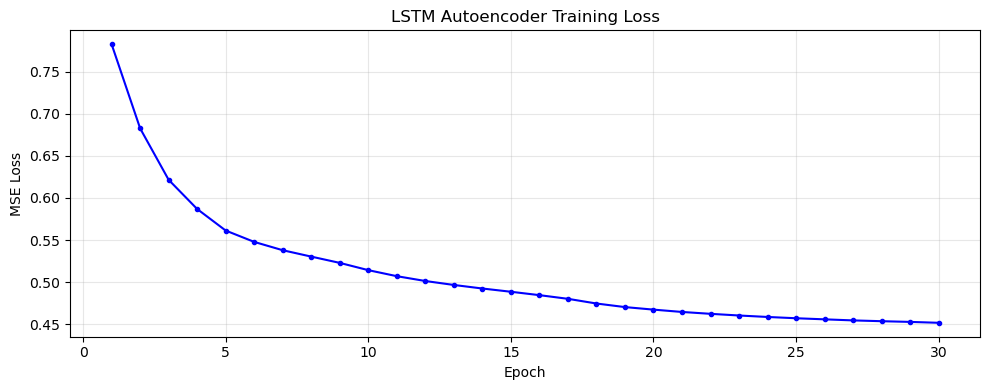

Final training loss: 0.451529


In [5]:
# ── TRAIN LSTM AUTOENCODER ────────────────────────────────────────
# Train only on healthy firms
# Model learns to reconstruct normal patterns
# Stressed firms will have higher reconstruction error

n_epochs = 30
train_losses = []

print("Training LSTM Autoencoder...")
print("(Trained only on healthy firms — learns normal patterns)\n")

model_lstm.train()
for epoch in range(n_epochs):
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        
        # Forward pass
        reconstruction = model_lstm(batch_X)
        loss = criterion(reconstruction, batch_X)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:2d}/{n_epochs}] Loss: {avg_loss:.6f}")

print("\n✅ Training complete")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(range(1, n_epochs+1), train_losses, marker='o', markersize=3, color='blue')
plt.title('LSTM Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/lstm_training_loss.png', dpi=150)
plt.show()
print(f"Final training loss: {train_losses[-1]:.6f}")

In [6]:
# ── COMPUTE RECONSTRUCTION ERRORS ────────────────────────────────
# Healthy firms → low reconstruction error (model knows their pattern)
# Stressed firms → high reconstruction error (model never saw them)

model_lstm.eval()
with torch.no_grad():
    reconstructions = model_lstm(X_all_tensor.to(device))
    
# Reconstruction error per sample (MSE)
reconstruction_errors = torch.mean(
    (X_all_tensor - reconstructions.cpu()) ** 2, dim=[1, 2]
).numpy()

# Split errors by actual label
errors_healthy  = reconstruction_errors[y == 0]
errors_stressed = reconstruction_errors[y == 1]

print("=== RECONSTRUCTION ERROR ANALYSIS ===")
print(f"\nHealthy firms:")
print(f"  Mean error:   {errors_healthy.mean():.4f}")
print(f"  Median error: {np.median(errors_healthy):.4f}")
print(f"  Std error:    {errors_healthy.std():.4f}")

print(f"\nStressed firms:")
print(f"  Mean error:   {errors_stressed.mean():.4f}")
print(f"  Median error: {np.median(errors_stressed):.4f}")
print(f"  Std error:    {errors_stressed.std():.4f}")

# AUC using reconstruction error as anomaly score
lstm_auc = roc_auc_score(y, reconstruction_errors)
print(f"\nLSTM Anomaly Detection AUC: {lstm_auc:.4f}")
print(f"(Higher error = more anomalous = more likely stressed)")

=== RECONSTRUCTION ERROR ANALYSIS ===

Healthy firms:
  Mean error:   0.4509
  Median error: 0.0539
  Std error:    11.5054

Stressed firms:
  Mean error:   0.7551
  Median error: 0.2386
  Std error:    2.4441

LSTM Anomaly Detection AUC: 0.6918
(Higher error = more anomalous = more likely stressed)


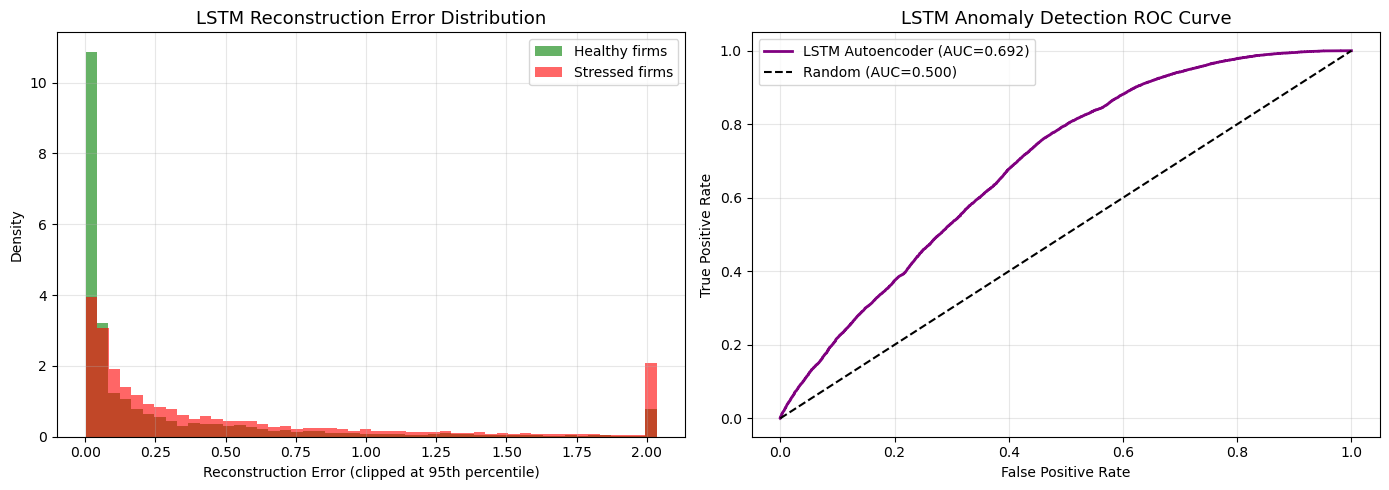

✅ LSTM plots saved
✅ Anomaly scores saved for ensemble model

=== WEEK 7 COMPLETE ===
LSTM Autoencoder AUC: 0.6918


In [7]:
# ── VISUALIZE RECONSTRUCTION ERRORS ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Error distribution (clipped for visibility)
clip_val = np.percentile(reconstruction_errors, 95)
axes[0].hist(np.clip(errors_healthy, 0, clip_val), bins=50,
             alpha=0.6, color='green', label='Healthy firms', density=True)
axes[0].hist(np.clip(errors_stressed, 0, clip_val), bins=50,
             alpha=0.6, color='red', label='Stressed firms', density=True)
axes[0].set_title('LSTM Reconstruction Error Distribution', fontsize=13)
axes[0].set_xlabel('Reconstruction Error (clipped at 95th percentile)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2 — ROC curve for anomaly detection
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y, reconstruction_errors)
axes[1].plot(fpr, tpr, color='purple', linewidth=2,
             label=f'LSTM Autoencoder (AUC={lstm_auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', label='Random (AUC=0.500)')
axes[1].set_title('LSTM Anomaly Detection ROC Curve', fontsize=13)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/lstm_anomaly_detection.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save reconstruction errors for the ensemble later
df['lstm_anomaly_score'] = reconstruction_errors
df[['lstm_anomaly_score', 'stress_label']].to_csv(
    '../data/processed/lstm_scores.csv', index=False)

print("✅ LSTM plots saved")
print("✅ Anomaly scores saved for ensemble model")
print(f"\n=== WEEK 7 COMPLETE ===")
print(f"LSTM Autoencoder AUC: {lstm_auc:.4f}")